# Libraries

In [465]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [466]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240425 - Ag60 GDE_0.3 M Na2SO4_pH3

17-Aug-26  01:13 AM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
06-Jun-26  09:44 PM    <DIR>          .ipynb_checkpoints
26-Apr-24  10:47 AM            40,220 0p3M_pH3 Na2SO4_20240426_0846_1min - Copy.xlsx
30-Jul-26  02:03 PM            47,571 0p3M_pH3 Na2SO4_20240426_0846_1min.xlsx
26-Apr-24  10:47 AM           279,266 0p3M_pH3 Na2SO4_20240426_0846_Line_1.csv
11-Jun-24  11:33 PM           295,818 20240423_Ag_GDE_0_3M_pH3_CD_Durat_FE_heatplot.png
19-Jul-25  07:41 PM           846,343 20240425 - Ag60 GDE_0.3 M Na2SO4_pH3.ipynb
17-Aug-26  01:13 AM           835,899 20240425 - Ag60 GDE_0.3 M Na2SO4_pH3-CORRECTED.ipynb
11-Aug-26  08:29 AM               639 20240425_0.3 M Na2SO4_pH3_Energy Consumption.csv
11-Aug-26  04:45 PM             5,614 20240425_0.3M Na2SO4_pH3.csv
11-Aug-26  08:29 AM        

# Load Data

In [467]:
Book = "Book_20240425 - Ag60 GDE_0.3 M Na2SO4_pH3.xlsx"
Book = pd.read_excel(Book)
Book.tail(10)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
34,Ag60 GDE in PTFE holder,60,56.400999,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-26 06:21:00,16.800000,0.855749,...,0.008407,0.063230,0.928354,0.000377,0.125513,0.944001,NaN,1.069514,0.063767,NaN
35,Ag60 GDE in PTFE holder,60,57.339428,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-26 06:46:00,17.216667,0.644907,...,0.006332,0.062396,0.931265,0.000372,0.096114,0.947049,NaN,1.043163,0.062794,101.738563
36,Ag60 GDE in PTFE holder,60,58.053172,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-26 07:29:00,17.933333,0.579604,...,0.005684,0.061509,0.932802,0.000370,0.087339,0.945201,NaN,1.032540,0.061861,NaN
37,Ag60 GDE in PTFE holder,60,59.164736,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-26 07:54:00,18.350000,0.564516,...,0.005542,0.060792,0.933660,0.000365,0.086795,0.952083,NaN,1.038878,0.061132,101.760976
38,Ag60 GDE in PTFE holder,60,59.029060,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-26 08:20:00,18.783333,0.549503,...,0.005391,0.060221,0.934382,0.000366,0.084237,0.940974,NaN,1.025211,0.060548,NaN
39,Ag60 GDE in PTFE holder,60,59.625524,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-26 08:37:00,19.066667,0.555385,...,0.005446,0.060061,0.934489,0.000292,0.085959,0.947952,NaN,1.033910,0.060390,101.907759
40,Ag60 GDE in PTFE holder,60,59.701971,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-26 08:54:00,19.350000,0.005824,...,0.000057,0.060202,0.939740,0.000302,0.000908,0.951402,NaN,0.952310,0.060206,NaN
41,Ag60 GDE in PTFE holder,60,59.285477,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-26 09:11:00,19.633333,0.533360,...,0.005235,0.059611,0.935149,0.000365,0.082152,0.935489,NaN,1.017641,0.059925,101.786274
42,Ag60 GDE in PTFE holder,60,59.948437,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-26 10:02:00,20.483333,0.540842,...,0.005308,0.059104,0.935582,0.000361,0.084232,0.937905,NaN,1.022137,0.059420,NaN
43,Ag60 GDE in PTFE holder,60,13.779827,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-26 10:55:00,21.366667,0.541335,...,0.005307,0.058764,0.935923,0.000385,0.019358,0.214348,NaN,0.233706,0.059078,101.896644


In [468]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min
41,Ag60 GDE in PTFE holder,60,59.29,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-26 09:11:00,19.63,0.533360,...,0.059611,0.935149,0.000365,0.082152,0.935489,NaN,1.017641,0.059925,101.786274,59.29
42,Ag60 GDE in PTFE holder,60,59.95,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-26 10:02:00,20.48,0.540842,...,0.059104,0.935582,0.000361,0.084232,0.937905,NaN,1.022137,0.059420,NaN,59.95
43,Ag60 GDE in PTFE holder,60,13.78,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-26 10:55:00,21.37,0.541335,...,0.058764,0.935923,0.000385,0.019358,0.214348,NaN,0.233706,0.059078,101.896644,13.78


### Temp from pH meter

In [469]:
Temp = "2024-04-26_105220.csv"
Temp = pd.read_csv(Temp, sep = ";")
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 23.712460815047024
Temp C median: 23.0


## Power supply/

In [470]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(2)

,U set,U ctul,I set,I ctul,P set,P ctul,R set,R ctul,R mode,Output/Input,Deice mode,Error,Time
0,0,0.79,0.0,0.000,320.00W,0.00W,N/,N/,N/,On,C,NaN,25-04-24 13:33
1,40,3.33,0.1,0.099,320.00W,0.00W,N/,N/,N/,On,CC,NaN,25-04-24 13:33


In [471]:
power_sup.groupby("I set", group_keys=True)[['U ctul']].apply(lambda x: x).head(3)

U ctul
I set          
0.0   0    0.79
0.1   1    3.33
      2    3.37

In [472]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    # format="%d/%m/%Y %H:%M:%S.%f"
    format="%d-%m-%y %H:%M"
)

# power_sup["I ctul"] = (
#     power_sup["I ctul"]
#     .str.replace("A", "", regex=False)
#     .str.strip()
#     .astype(float)
# )
# power_sup["U ctul"] = (
#     power_sup["U ctul"]
#     .str.replace("V", "", regex=False)
#     .str.strip()
#     .astype(float)
# )

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I ctul": "median",
        "U ctul": "median"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                  Time  I ctul  U ctul
0  2024-04-25 12:00:00   0.099    3.39
1  2024-04-25 14:00:00   0.099    3.45
2  2024-04-25 16:00:00   0.255    4.32
3  2024-04-25 18:00:00   0.502    5.47
4  2024-04-25 20:00:00   0.745    6.39
5  2024-04-25 22:00:00   1.000    7.04
6  2024-04-26 00:00:00   1.495    8.59
7  2024-04-26 02:00:00   1.986   10.01
8  2024-04-26 04:00:00   2.987   12.09
9  2024-04-26 06:00:00   0.501    5.23
10 2024-04-26 08:00:00   0.502    5.30
11 2024-04-26 10:00:00   0.502    5.33


In [473]:
# cell_voltage = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[1:].reset_index(drop=True)
power_summary = power_summary.iloc[:-3].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I ctul  U ctul
0 2024-04-25 14:00:00   0.099    3.45
1 2024-04-25 16:00:00   0.255    4.32
2 2024-04-25 18:00:00   0.502    5.47
3 2024-04-25 20:00:00   0.745    6.39
4 2024-04-25 22:00:00   1.000    7.04
5 2024-04-26 00:00:00   1.495    8.59
6 2024-04-26 02:00:00   1.986   10.01
7 2024-04-26 04:00:00   2.987   12.09


In [474]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U ctul": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I ctul")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I ctul,
0.099,3.45
0.255,4.32
0.502,5.47
0.745,6.39
1.000,7.04
1.495,8.59
1.986,10.01
2.987,12.09


In [475]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I ctul,,
0.099,3.45,0.99
0.255,4.32,2.55
0.502,5.47,5.02
0.745,6.39,7.45
1.000,7.04,10.00
1.495,8.59,14.95
1.986,10.01,19.86
2.987,12.09,29.87


## Flow rate

In [476]:
flow_rate = "0p3M_pH3 Na2SO4_20240426_0846_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(20)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-04-26 08:46:52.291000,NaN
1,Software version,Aurora 1.0.6,NaN
2,Instrument name,0p3M_pH3 Na2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6f:0d:ec,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [477]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})
flow_rate.head(10)

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-04-25 11:39:59.990000,47.730443,23.865222
1,2024-04-25 11:41:00.038000,47.602198,23.801099
2,2024-04-25 11:42:00,46.481747,23.240873
3,2024-04-25 11:42:59.962000,45.346312,22.673156
4,2024-04-25 11:44:00.010000,43.91369,21.956845
5,2024-04-25 11:44:59.971000,43.75641,21.878205
6,2024-04-25 11:46:00.019000,43.811953,21.905977
7,2024-04-25 11:46:59.981000,43.173603,21.586801
8,2024-04-25 11:48:00.029000,43.350471,21.675236
9,2024-04-25 11:48:59.990000,43.243314,21.621657


In [478]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-04-25 10:00:00     42.977333     47.730443       44.17566   
1 2024-04-25 12:00:00     43.906745     58.417604      52.673718   
2 2024-04-25 14:00:00     56.932429     60.495722      58.864677   
3 2024-04-25 16:00:00     59.268646     62.979984      60.940803   
4 2024-04-25 18:00:00     60.203903     63.570871      61.793343   
5 2024-04-25 20:00:00     61.165238     66.761374      62.871322   
6 2024-04-25 22:00:00     63.173743     69.692052      65.630679   
7 2024-04-26 00:00:00      67.20242     79.616067      69.806859   
8 2024-04-26 02:00:00     54.779461     79.479179      74.139691   
9 2024-04-26 04:00:00     55.563013     58.144243      57.016477   

  Flow_rate_median  
0        43.608332  
1        53.626923  
2         58.88708  
3        60.919358  
4        61.774997  
5        62.565017  
6        65.199585  
7        68.436882  
8        76.643064  
9        57.133079  


#### Correction for dry flow

In [479]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.300 L/mol
p_sat = 2.8098 kPa -> x(H2O) = 2.77 % -> dry factor 0.97227


In [480]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [481]:
print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-04-25 10:00:00     42.977333     47.730443       44.17566   
1 2024-04-25 12:00:00     43.906745     58.417604      52.673718   
2 2024-04-25 14:00:00     56.932429     60.495722      58.864677   
3 2024-04-25 16:00:00     59.268646     62.979984      60.940803   
4 2024-04-25 18:00:00     60.203903     63.570871      61.793343   
5 2024-04-25 20:00:00     61.165238     66.761374      62.871322   
6 2024-04-25 22:00:00     63.173743     69.692052      65.630679   
7 2024-04-26 00:00:00      67.20242     79.616067      69.806859   
8 2024-04-26 02:00:00     54.779461     79.479179      74.139691   
9 2024-04-26 04:00:00     55.563013     58.144243      57.016477   

  Flow_rate_median Flow_rate_min_dry Flow_rate_max_dry Flow_rate_mean_dry  \
0        43.608332         41.785527         46.406828          42.950623   
1        53.626923         42.689165         56.797623          51.213022   
2         58.88708  

In [482]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I ctul']
dfflow_rate['Voltage'] = power_summary['U ctul']
dfflow_rate = dfflow_rate.iloc[:-2].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-04-25 10:00:00,42.977333,47.730443,44.17566,43.608332,41.785527,46.406828,42.950623,42.399028,0.099,3.45
1,2024-04-25 12:00:00,43.906745,58.417604,52.673718,53.626923,42.689165,56.797623,51.213022,52.139793,0.255,4.32
2,2024-04-25 14:00:00,56.932429,60.495722,58.864677,58.88708,55.353634,58.818113,57.232298,57.25408,0.502,5.47
3,2024-04-25 16:00:00,59.268646,62.979984,60.940803,60.919358,57.625065,61.233484,59.250852,59.23,0.745,6.39
4,2024-04-25 18:00:00,60.203903,63.570871,61.793343,61.774997,58.534386,61.807985,60.07975,60.061912,1.000,7.04
5,2024-04-25 20:00:00,61.165238,66.761374,62.871322,62.565017,59.469062,64.910012,61.127835,60.830024,1.495,8.59
6,2024-04-25 22:00:00,63.173743,69.692052,65.630679,65.199585,61.421869,67.759419,63.810672,63.391532,1.986,10.01
7,2024-04-26 00:00:00,67.20242,79.616067,69.806859,68.436882,65.338827,77.408231,67.871042,66.539056,2.987,12.09


In [485]:
# dfflow_rate.to_csv('20240425_0.3M Na2SO4_pH3_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J <br>

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [486]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I ctul,,,
0.099,3.45,0.99,99.0
0.255,4.32,2.55,255.0
0.502,5.47,5.02,502.0


In [487]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I ctul,,,,
0.099,3.45,0.99,99.0,2459.160
0.255,4.32,2.55,255.0,7931.520
0.502,5.47,5.02,502.0,19770.768
0.745,6.39,7.45,745.0,34275.960
1.000,7.04,10.00,1000.0,50688.000
1.495,8.59,14.95,1495.0,92462.760
1.986,10.01,19.86,1986.0,143134.992
2.987,12.09,29.87,2987.0,260012.376


In [488]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I ctul,,,,,
0.099,3.45,0.99,99.0,2459.160,0.000683
0.255,4.32,2.55,255.0,7931.520,0.002203
0.502,5.47,5.02,502.0,19770.768,0.005492
0.745,6.39,7.45,745.0,34275.960,0.009521
1.000,7.04,10.00,1000.0,50688.000,0.014080
1.495,8.59,14.95,1495.0,92462.760,0.025684
1.986,10.01,19.86,1986.0,143134.992,0.039760
2.987,12.09,29.87,2987.0,260012.376,0.072226


In [490]:
dfcell_voltage.to_csv('20240425_0.3 M Na2SO4_pH3_Energy Consumption.csv')

## Integer Duration ("Applied Current /A" - Values optimization)

In [491]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60,0.00,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-04-25 13:33:00,0.00,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.00,0.0
1,Ag60 GDE in PTFE holder,60,47.46,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.099,2024-04-25 14:12:00,0.65,0.075531,...,0.937991,0.010238,0.047033,0.990127,NaN,1.037160,0.016365,97.239286,47.46,0.0
2,Ag60 GDE in PTFE holder,60,54.03,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.099,2024-04-25 15:14:00,1.68,0.094763,...,0.985024,0.001195,0.067457,1.014028,NaN,1.081485,0.014052,NaN,54.03,1.0
3,Ag60 GDE in PTFE holder,60,58.32,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.275,2024-04-25 15:57:00,2.40,0.156546,...,0.968485,0.000747,0.042988,0.841454,NaN,0.884441,0.030026,101.972517,58.32,2.0
4,Ag60 GDE in PTFE holder,60,59.15,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.275,2024-04-25 16:49:00,3.27,0.151140,...,0.964616,0.000551,0.042235,0.965041,NaN,1.007276,0.033948,NaN,59.15,3.0
5,Ag60 GDE in PTFE holder,60,59.32,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.275,2024-04-25 17:15:00,3.70,0.147746,...,0.964718,0.000480,0.041358,0.965946,NaN,1.007304,0.033881,101.847222,59.32,3.0
6,Ag60 GDE in PTFE holder,60,59.24,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-25 17:40:00,4.12,0.146012,...,0.964861,0.000423,0.021599,0.508220,NaN,0.529819,0.033754,NaN,59.24,4.0
7,Ag60 GDE in PTFE holder,60,60.26,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-25 18:06:00,4.55,0.308931,...,0.939877,0.000429,0.046577,0.875591,NaN,0.922168,0.057257,101.609630,60.26,4.0
8,Ag60 GDE in PTFE holder,60,61.22,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-25 18:31:00,4.97,0.354667,...,0.937537,0.000419,0.054428,0.918765,NaN,0.973193,0.059173,NaN,61.22,4.0
9,Ag60 GDE in PTFE holder,60,60.45,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-25 18:57:00,5.40,0.347065,...,0.937437,0.000413,0.052601,0.909895,NaN,0.962496,0.059343,101.394989,60.45,5.0


# Current density

In [492]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #mA
Book.head(5)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,0.00,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-04-25 13:33:00,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.00,0.0,0.0
1,Ag60 GDE in PTFE holder,60,47.46,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.099,2024-04-25 14:12:00,0.65,0.075531,...,0.010238,0.047033,0.990127,NaN,1.037160,0.016365,97.239286,47.46,0.0,-99.0
2,Ag60 GDE in PTFE holder,60,54.03,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.099,2024-04-25 15:14:00,1.68,0.094763,...,0.001195,0.067457,1.014028,NaN,1.081485,0.014052,NaN,54.03,1.0,-99.0
3,Ag60 GDE in PTFE holder,60,58.32,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.275,2024-04-25 15:57:00,2.40,0.156546,...,0.000747,0.042988,0.841454,NaN,0.884441,0.030026,101.972517,58.32,2.0,-275.0
4,Ag60 GDE in PTFE holder,60,59.15,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.275,2024-04-25 16:49:00,3.27,0.151140,...,0.000551,0.042235,0.965041,NaN,1.007276,0.033948,NaN,59.15,3.0,-275.0


## FE(CO)

In [493]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [494]:
# # ---- physical constants ----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.300 L/mol


In [495]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.099, 0.255, 0.502, 0.745, 1.0, 1.495, 1.986, 2.987]

In [496]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[3, 3, 5, 5, 3, 5, 4, 5]

In [497]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))
# rows[["c(H2)", "c(CO)","FE(H2)", "FE(CO)"]].head(50)

                     c(H2)  c(CO)
Applied current / A              
0.099                0.001  0.014
0.255                0.001  0.034
0.502                0.003  0.059
0.745                0.011  0.078
1.000                0.024  0.090
1.495                0.059  0.102
1.986                0.099  0.104
2.987                0.182  0.096


In [498]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 95.7 / 82.6 %


In [499]:
rows[rows["FE(total)"]>100 ]

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)


In [500]:
rows = rows.drop(rows[rows['FE(total)'] > 105].index) #Noise in the first measurements
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
0,Ag60 GDE in PTFE holder,60,0.00,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.099,2024-04-25 13:33:00,0.00,0.000000,...,0.00,0.0,-99.0,0.000,0.099,42.950623,41.785527,46.406828,42.399028,0.000000
1,Ag60 GDE in PTFE holder,60,47.46,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.099,2024-04-25 14:12:00,0.65,0.075531,...,47.46,0.0,-99.0,0.099,0.099,42.950623,41.785527,46.406828,42.399028,92.658696
2,Ag60 GDE in PTFE holder,60,54.03,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.099,2024-04-25 15:14:00,1.68,0.094763,...,54.03,1.0,-99.0,0.099,0.099,42.950623,41.785527,46.406828,42.399028,84.869116
3,Ag60 GDE in PTFE holder,60,58.32,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.255,2024-04-25 15:57:00,2.40,0.156546,...,58.32,2.0,-255.0,0.275,0.255,51.213022,42.689165,56.797623,52.139793,85.276479
4,Ag60 GDE in PTFE holder,60,59.15,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.255,2024-04-25 16:49:00,3.27,0.151140,...,59.15,3.0,-255.0,0.275,0.255,51.213022,42.689165,56.797623,52.139793,95.749004
5,Ag60 GDE in PTFE holder,60,59.32,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.255,2024-04-25 17:15:00,3.70,0.147746,...,59.32,3.0,-255.0,0.275,0.255,51.213022,42.689165,56.797623,52.139793,95.475087
6,Ag60 GDE in PTFE holder,60,61.61,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 19:22:00,5.82,0.316839,...,61.61,5.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,94.367125
7,Ag60 GDE in PTFE holder,60,60.45,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 18:57:00,5.40,0.347065,...,60.45,5.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,94.432951
8,Ag60 GDE in PTFE holder,60,61.22,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 18:31:00,4.97,0.354667,...,61.22,4.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,94.282832
9,Ag60 GDE in PTFE holder,60,60.26,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 18:06:00,4.55,0.308931,...,60.26,4.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,90.751216


In [501]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.4].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.12].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.25].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.1].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,47.46,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.099,2024-04-25 14:12:00,0.65,0.075531,...,47.46,0.0,-99.0,0.099,0.099,42.950623,41.785527,46.406828,42.399028,92.658696
2,Ag60 GDE in PTFE holder,60,54.03,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.099,2024-04-25 15:14:00,1.68,0.094763,...,54.03,1.0,-99.0,0.099,0.099,42.950623,41.785527,46.406828,42.399028,84.869116
4,Ag60 GDE in PTFE holder,60,59.15,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.255,2024-04-25 16:49:00,3.27,0.151140,...,59.15,3.0,-255.0,0.275,0.255,51.213022,42.689165,56.797623,52.139793,95.749004
5,Ag60 GDE in PTFE holder,60,59.32,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.255,2024-04-25 17:15:00,3.70,0.147746,...,59.32,3.0,-255.0,0.275,0.255,51.213022,42.689165,56.797623,52.139793,95.475087
6,Ag60 GDE in PTFE holder,60,61.61,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 19:22:00,5.82,0.316839,...,61.61,5.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,94.367125
7,Ag60 GDE in PTFE holder,60,60.45,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 18:57:00,5.40,0.347065,...,60.45,5.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,94.432951
8,Ag60 GDE in PTFE holder,60,61.22,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 18:31:00,4.97,0.354667,...,61.22,4.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,94.282832
9,Ag60 GDE in PTFE holder,60,60.26,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 18:06:00,4.55,0.308931,...,60.26,4.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,90.751216
12,Ag60 GDE in PTFE holder,60,61.96,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.745,2024-04-25 20:13:00,6.67,1.046424,...,61.96,6.0,-745.0,0.760,0.745,59.250852,57.625065,61.233484,59.23,91.520414
13,Ag60 GDE in PTFE holder,60,61.92,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.745,2024-04-25 20:39:00,7.10,1.103708,...,61.92,7.0,-745.0,0.760,0.745,59.250852,57.625065,61.233484,59.23,93.095374


### Mean FE per current density

In [502]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0         99    4.747745   84.016161      4.747745     84.016161   0.545884   
1        255    3.967379   91.644667      3.967379     91.644667   0.047353   
2        502    4.932835   88.525696      4.937373     89.140997   0.167712   
3        745   11.326896   81.719341     11.424690     81.833373   0.168578   
4       1000   18.805130   71.180858     19.257939     71.430207   0.473943   
5       1495   31.504825   54.736225     31.790100     54.986783   0.512423   
6       1986   39.284668   44.104327     41.992658     44.103099   3.277626   
7       2987   49.256245   28.752612     53.719822     28.385062   4.715198   

   FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  ...  c_H2_mean  c_H2_median  n  \
0   4.440674   0.771997   6.280062   4.474803  ...   0.000838     0.000838  2   
1   0.089605   0.066968   0.126720   3.943702  ...   0.001466     0.001466  2   
2   0.797058   0.335425   1.594115   4.681343

## FE(H2)

In [503]:
# Book["FE(H2)"] = Book["c(H2)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]
print(rows["FE(H2)"])

1      4.201861
2      5.293629
4      4.014732
5      3.920025
6      4.713910
7      5.160836
8      5.272952
9      4.583641
12    10.840050
13    11.429562
14    11.618151
15    11.419819
16    19.299898
17    17.857554
18    19.257939
20    30.051646
21    31.569419
22    32.010781
23    32.387455
24    29.541694
25    41.445320
26    42.539996
27    43.611663
28    54.787182
29    30.641849
30    51.274872
31    53.719822
32    55.857498
Name: FE(H2), dtype: float64


In [504]:
# FE(H2) was already set above (= FE_H2); nothing to recompute here.
Book[["FE(H2)", "FE(CO)"]].describe()

,FE(H2),FE(CO)
count,33.000000,33.000000
mean,0.221218,0.642591
std,0.194251,0.256664
min,0.000000,0.000000
25%,0.052601,0.450586
50%,0.139191,0.667915
75%,0.339597,0.841454
max,0.616588,1.014028


# Plots

## Current Density vs Time

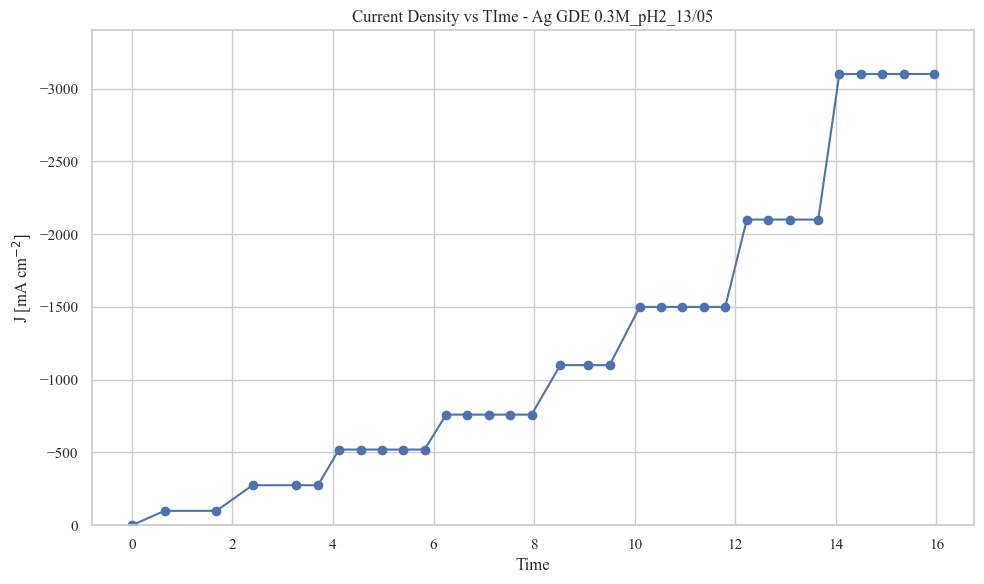

In [505]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.3M_pH2_13/05')  
plt.xlabel('Time') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

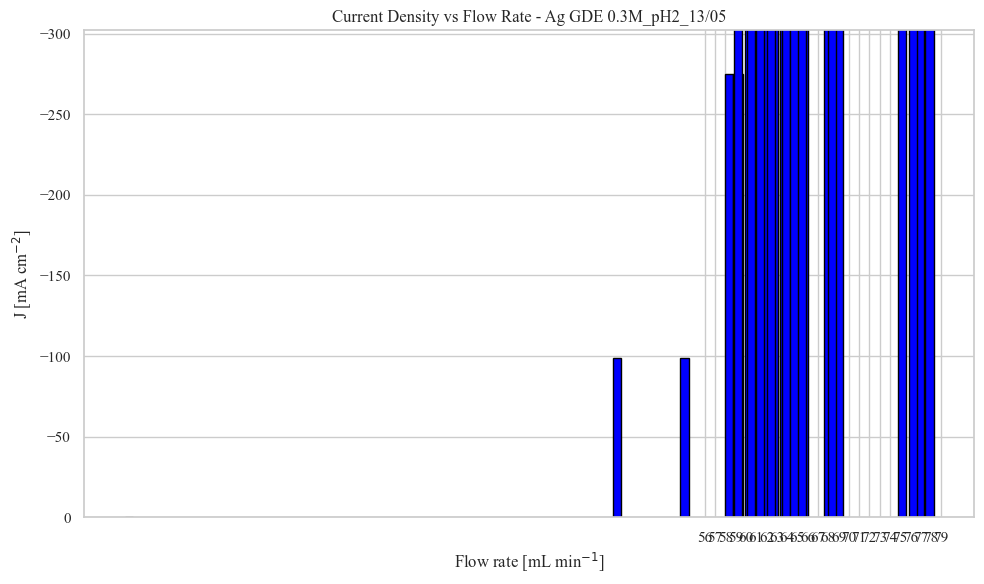

In [506]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Current Density'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.3M_pH2_13/05')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -302)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


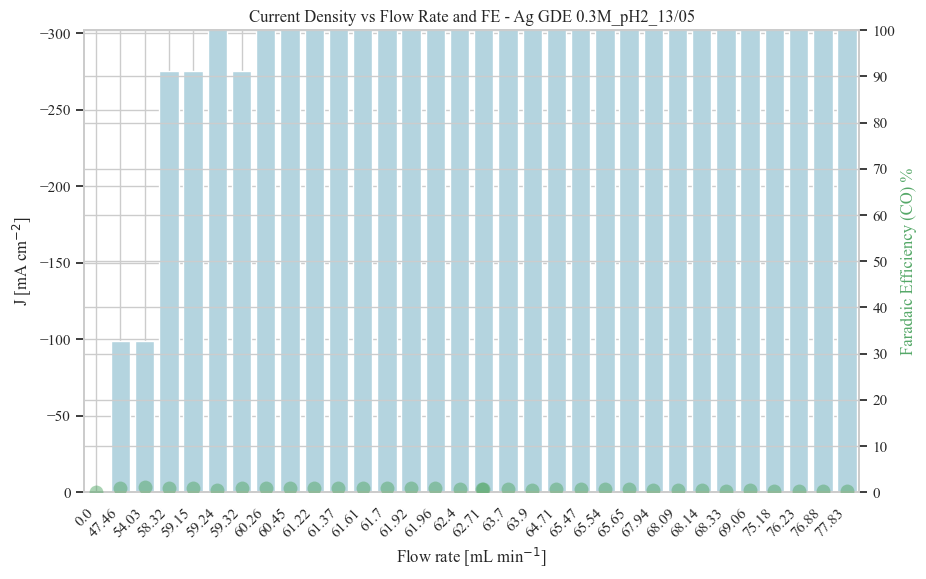

In [507]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Current Density', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.3M_pH2_13/05')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [mA cm$^{-2}$]')
ax1.set_ylim(0, -302)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240513_Ag_GDE_0_3M_pH2_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [508]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [509]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240425 - Ag60 GDE_0.3 M Na2SO4_pH3

17-Aug-26  01:13 AM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
06-Jun-26  09:44 PM    <DIR>          .ipynb_checkpoints
26-Apr-24  10:47 AM            40,220 0p3M_pH3 Na2SO4_20240426_0846_1min - Copy.xlsx
30-Jul-26  02:03 PM            47,571 0p3M_pH3 Na2SO4_20240426_0846_1min.xlsx
26-Apr-24  10:47 AM           279,266 0p3M_pH3 Na2SO4_20240426_0846_Line_1.csv
11-Jun-24  11:33 PM           295,818 20240423_Ag_GDE_0_3M_pH3_CD_Durat_FE_heatplot.png
19-Jul-25  07:41 PM           846,343 20240425 - Ag60 GDE_0.3 M Na2SO4_pH3.ipynb
17-Aug-26  01:13 AM           835,899 20240425 - Ag60 GDE_0.3 M Na2SO4_pH3-CORRECTED.ipynb
17-Aug-26  01:27 AM               549 20240425_0.3 M Na2SO4_pH3_Energy Consumption.csv
11-Aug-26  04:45 PM             5,614 20240425_0.3M Na2SO4_pH3.csv
17-Aug-26  01:27 AM        

In [510]:
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,47.46,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.099,2024-04-25 14:12:00,0.65,0.075531,...,47.46,0.0,-99.0,0.099,0.099,42.950623,41.785527,46.406828,42.399028,92.658696
2,Ag60 GDE in PTFE holder,60,54.03,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.099,2024-04-25 15:14:00,1.68,0.094763,...,54.03,1.0,-99.0,0.099,0.099,42.950623,41.785527,46.406828,42.399028,84.869116
4,Ag60 GDE in PTFE holder,60,59.15,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.255,2024-04-25 16:49:00,3.27,0.151140,...,59.15,3.0,-255.0,0.275,0.255,51.213022,42.689165,56.797623,52.139793,95.749004
5,Ag60 GDE in PTFE holder,60,59.32,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.255,2024-04-25 17:15:00,3.70,0.147746,...,59.32,3.0,-255.0,0.275,0.255,51.213022,42.689165,56.797623,52.139793,95.475087
6,Ag60 GDE in PTFE holder,60,61.61,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 19:22:00,5.82,0.316839,...,61.61,5.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,94.367125
7,Ag60 GDE in PTFE holder,60,60.45,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 18:57:00,5.40,0.347065,...,60.45,5.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,94.432951
8,Ag60 GDE in PTFE holder,60,61.22,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 18:31:00,4.97,0.354667,...,61.22,4.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,94.282832
9,Ag60 GDE in PTFE holder,60,60.26,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 18:06:00,4.55,0.308931,...,60.26,4.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,90.751216
12,Ag60 GDE in PTFE holder,60,61.96,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.745,2024-04-25 20:13:00,6.67,1.046424,...,61.96,6.0,-745.0,0.760,0.745,59.250852,57.625065,61.233484,59.23,91.520414
13,Ag60 GDE in PTFE holder,60,61.92,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.745,2024-04-25 20:39:00,7.10,1.103708,...,61.92,7.0,-745.0,0.760,0.745,59.250852,57.625065,61.233484,59.23,93.095374


## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


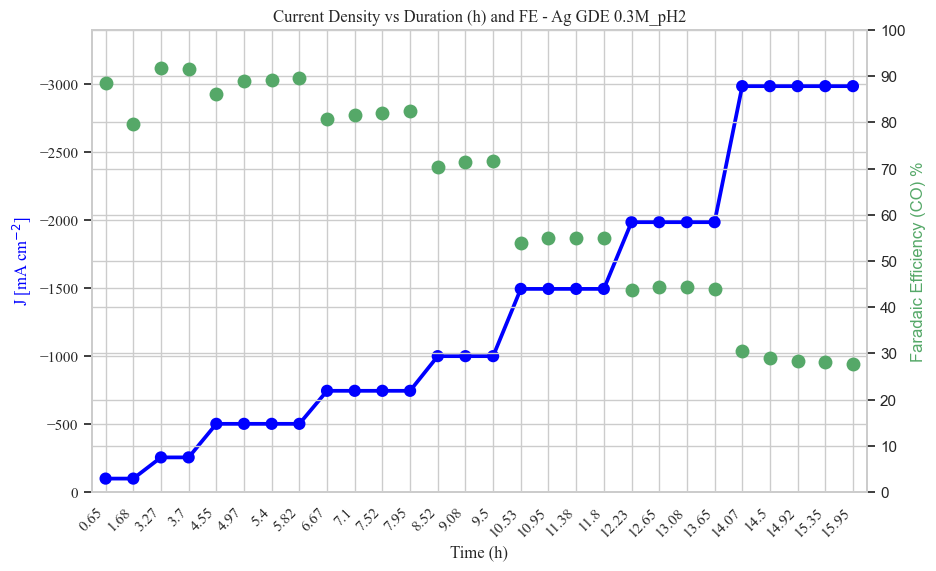

In [511]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=rows, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.3M_pH2')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=rows, x='Duration / h',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240513_Ag_GDE_0_3M_pH2_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

### Drop points from initial step in each current

In [512]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.4].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.12].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.25].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.1].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,47.46,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.099,2024-04-25 14:12:00,0.65,0.075531,...,47.46,0.0,-99.0,0.099,0.099,42.950623,41.785527,46.406828,42.399028,92.658696
2,Ag60 GDE in PTFE holder,60,54.03,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.099,2024-04-25 15:14:00,1.68,0.094763,...,54.03,1.0,-99.0,0.099,0.099,42.950623,41.785527,46.406828,42.399028,84.869116
4,Ag60 GDE in PTFE holder,60,59.15,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.255,2024-04-25 16:49:00,3.27,0.151140,...,59.15,3.0,-255.0,0.275,0.255,51.213022,42.689165,56.797623,52.139793,95.749004
5,Ag60 GDE in PTFE holder,60,59.32,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.255,2024-04-25 17:15:00,3.70,0.147746,...,59.32,3.0,-255.0,0.275,0.255,51.213022,42.689165,56.797623,52.139793,95.475087
6,Ag60 GDE in PTFE holder,60,61.61,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 19:22:00,5.82,0.316839,...,61.61,5.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,94.367125
7,Ag60 GDE in PTFE holder,60,60.45,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 18:57:00,5.40,0.347065,...,60.45,5.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,94.432951
8,Ag60 GDE in PTFE holder,60,61.22,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 18:31:00,4.97,0.354667,...,61.22,4.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,94.282832
9,Ag60 GDE in PTFE holder,60,60.26,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.502,2024-04-25 18:06:00,4.55,0.308931,...,60.26,4.0,-502.0,0.520,0.502,57.232298,55.353634,58.818113,57.25408,90.751216
12,Ag60 GDE in PTFE holder,60,61.96,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.745,2024-04-25 20:13:00,6.67,1.046424,...,61.96,6.0,-745.0,0.760,0.745,59.250852,57.625065,61.233484,59.23,91.520414
13,Ag60 GDE in PTFE holder,60,61.92,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.745,2024-04-25 20:39:00,7.10,1.103708,...,61.92,7.0,-745.0,0.760,0.745,59.250852,57.625065,61.233484,59.23,93.095374


## Current Density vs FE(CO)_ mean and std

## Stacked bar plot

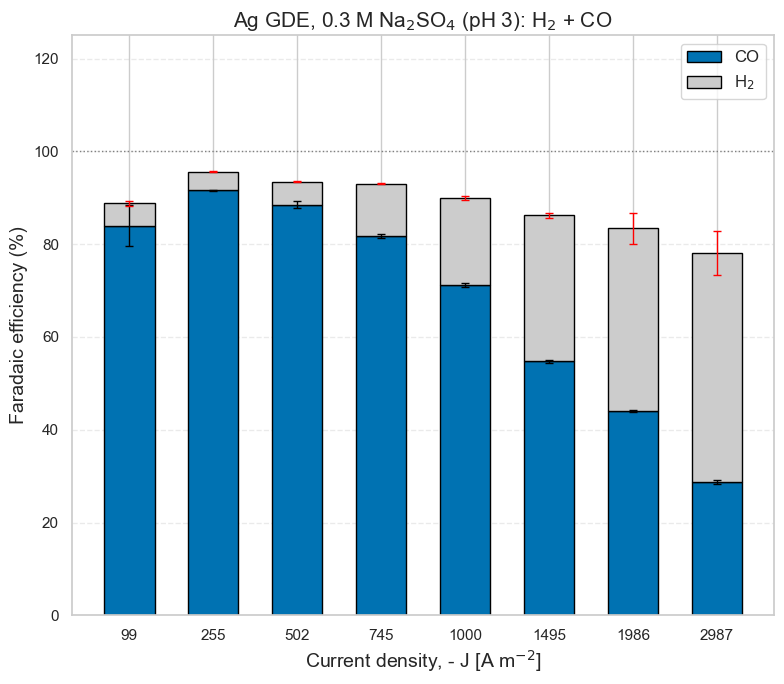

In [513]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.3 M Na$_2$SO$_4$ (pH 3): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

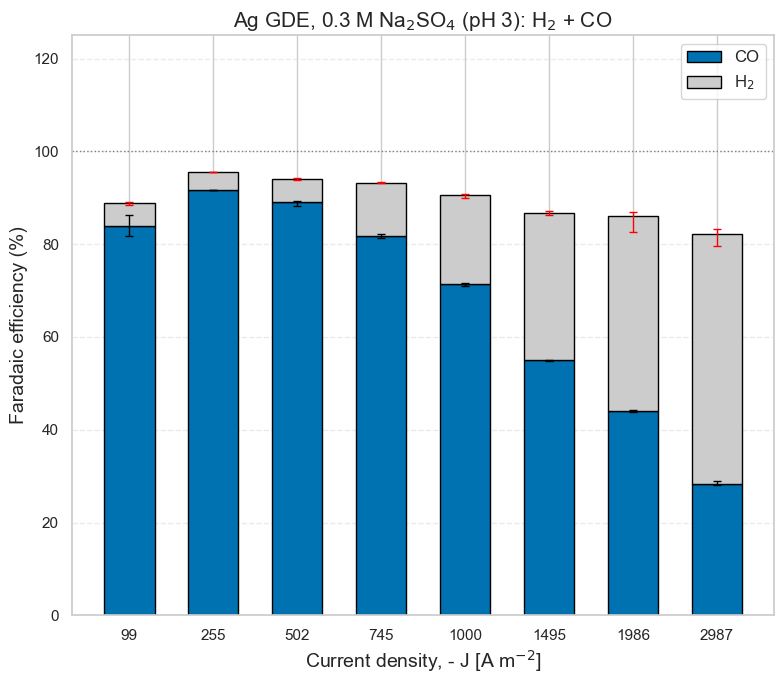

In [514]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(
    r"Ag GDE, 0.3 M Na$_2$SO$_4$ (pH 3): H$_2$ + CO",
    fontsize=15
)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [515]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [516]:
summary

,J (A m-2),FE_H2_mean,FE_CO_mean,FE_H2_median,FE_CO_median,FE_H2_sem,FE_CO_sem,FE_H2_std,FE_CO_std,FE_H2_q25,...,c_H2_median,n,FE_H2_err_low,FE_H2_err_high,FE_CO_err_low,FE_CO_err_high,FE_total_err_low,FE_total_err_high,Time Interval (h),J (A m-2)_ps
0,100,4.747745,84.016161,4.747745,84.016161,0.545884,4.440674,0.771997,6.280062,4.474803,...,0.000838,2,0.272942,0.272942,2.220337,2.220337,1.947395,1.947395,0–2,99
1,250,3.967379,91.644667,3.967379,91.644667,0.047353,0.089605,0.066968,0.126720,3.943702,...,0.001466,2,0.023677,0.023677,0.044802,0.044802,0.068479,0.068479,2–4,255
2,500,4.932835,88.525696,4.937373,89.140997,0.167712,0.797058,0.335425,1.594115,4.681343,...,0.003271,4,0.256030,0.251492,0.841694,0.226392,0.925051,0.058603,4–6,502
3,750,11.326896,81.719341,11.424690,81.833373,0.168578,0.389360,0.337157,0.778721,11.274877,...,0.010857,4,0.149814,0.052019,0.413923,0.299891,0.655595,0.344603,6–8,745
4,1000,18.805130,71.180858,19.257939,71.430207,0.473943,0.416969,0.820893,0.722211,18.557746,...,0.024226,3,0.700192,0.020979,0.531597,0.157575,1.231789,0.178554,8–10,1000
5,1500,31.504825,54.736225,31.790100,54.986783,0.512423,0.251450,1.024846,0.502901,31.189976,...,0.059031,4,0.600124,0.314849,0.252530,0.001973,0.851551,0.313512,10–12,1495
6,2000,39.284668,44.104327,41.992658,44.103099,3.277626,0.175559,6.555253,0.351118,38.469413,...,0.099400,4,3.523245,0.815255,0.257064,0.258292,3.632271,0.629434,12–14,1986
7,3000,49.256245,28.752612,53.719822,28.385062,4.715198,0.493325,10.543504,1.103109,51.274872,...,0.182205,5,2.444950,1.067360,0.199791,0.603770,1.841180,0.867569,14–16,2987


In [517]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,4.747745,84.016161,4.747745,84.016161,0.545884,4.440674,0.771997,6.280062,4.474803,...,0.000838,2,0.272942,0.272942,2.220337,2.220337,1.947395,1.947395,0–2,99
1,250,3.967379,91.644667,3.967379,91.644667,0.047353,0.089605,0.066968,0.126720,3.943702,...,0.001466,2,0.023677,0.023677,0.044802,0.044802,0.068479,0.068479,2–4,255
2,500,4.932835,88.525696,4.937373,89.140997,0.167712,0.797058,0.335425,1.594115,4.681343,...,0.003271,4,0.256030,0.251492,0.841694,0.226392,0.925051,0.058603,4–6,502
3,750,11.326896,81.719341,11.424690,81.833373,0.168578,0.389360,0.337157,0.778721,11.274877,...,0.010857,4,0.149814,0.052019,0.413923,0.299891,0.655595,0.344603,6–8,745
4,1000,18.805130,71.180858,19.257939,71.430207,0.473943,0.416969,0.820893,0.722211,18.557746,...,0.024226,3,0.700192,0.020979,0.531597,0.157575,1.231789,0.178554,8–10,1000
5,1500,31.504825,54.736225,31.790100,54.986783,0.512423,0.251450,1.024846,0.502901,31.189976,...,0.059031,4,0.600124,0.314849,0.252530,0.001973,0.851551,0.313512,10–12,1495
6,2000,39.284668,44.104327,41.992658,44.103099,3.277626,0.175559,6.555253,0.351118,38.469413,...,0.099400,4,3.523245,0.815255,0.257064,0.258292,3.632271,0.629434,12–14,1986
7,3000,49.256245,28.752612,53.719822,28.385062,4.715198,0.493325,10.543504,1.103109,51.274872,...,0.182205,5,2.444950,1.067360,0.199791,0.603770,1.841180,0.867569,14–16,2987


In [520]:
Res_Book
# Res_Book.to_csv('20240425_0.3M Na2SO4_pH3.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,4.747745,84.016161,4.747745,84.016161,0.545884,4.440674,0.771997,6.280062,4.474803,...,0.000838,2,0.272942,0.272942,2.220337,2.220337,1.947395,1.947395,0–2,99
1,250,3.967379,91.644667,3.967379,91.644667,0.047353,0.089605,0.066968,0.126720,3.943702,...,0.001466,2,0.023677,0.023677,0.044802,0.044802,0.068479,0.068479,2–4,255
2,500,4.932835,88.525696,4.937373,89.140997,0.167712,0.797058,0.335425,1.594115,4.681343,...,0.003271,4,0.256030,0.251492,0.841694,0.226392,0.925051,0.058603,4–6,502
3,750,11.326896,81.719341,11.424690,81.833373,0.168578,0.389360,0.337157,0.778721,11.274877,...,0.010857,4,0.149814,0.052019,0.413923,0.299891,0.655595,0.344603,6–8,745
4,1000,18.805130,71.180858,19.257939,71.430207,0.473943,0.416969,0.820893,0.722211,18.557746,...,0.024226,3,0.700192,0.020979,0.531597,0.157575,1.231789,0.178554,8–10,1000
5,1500,31.504825,54.736225,31.790100,54.986783,0.512423,0.251450,1.024846,0.502901,31.189976,...,0.059031,4,0.600124,0.314849,0.252530,0.001973,0.851551,0.313512,10–12,1495
6,2000,39.284668,44.104327,41.992658,44.103099,3.277626,0.175559,6.555253,0.351118,38.469413,...,0.099400,4,3.523245,0.815255,0.257064,0.258292,3.632271,0.629434,12–14,1986
7,3000,49.256245,28.752612,53.719822,28.385062,4.715198,0.493325,10.543504,1.103109,51.274872,...,0.182205,5,2.444950,1.067360,0.199791,0.603770,1.841180,0.867569,14–16,2987


## Mean and StD of FE(CO) through time

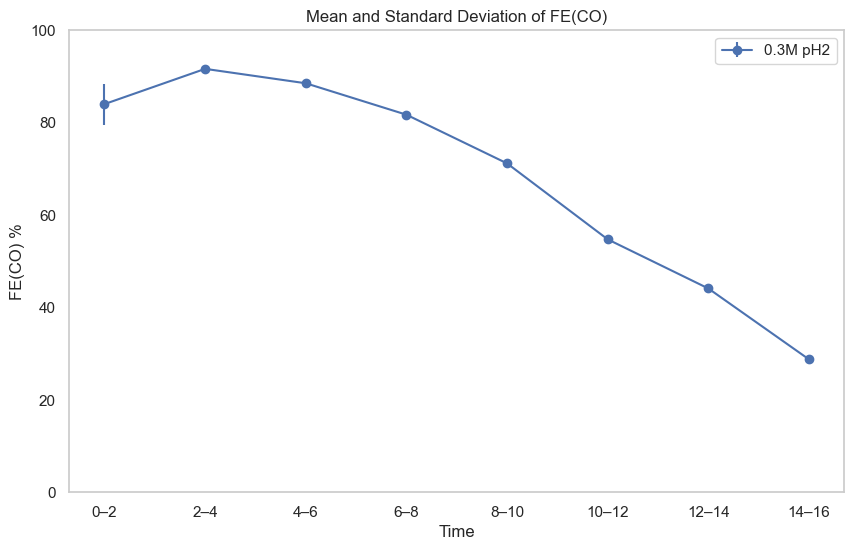

In [521]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Applied Current mean with standard deviation
# ax.errorbar(resampled_df.index, resampled_df['Applied current / A_mean'], 
#             yerr=resampled_df['Applied current / A_std'], fmt='-o', label='Applied current / A_mean')

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.3M pH2')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240513_0.3M_pH2_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

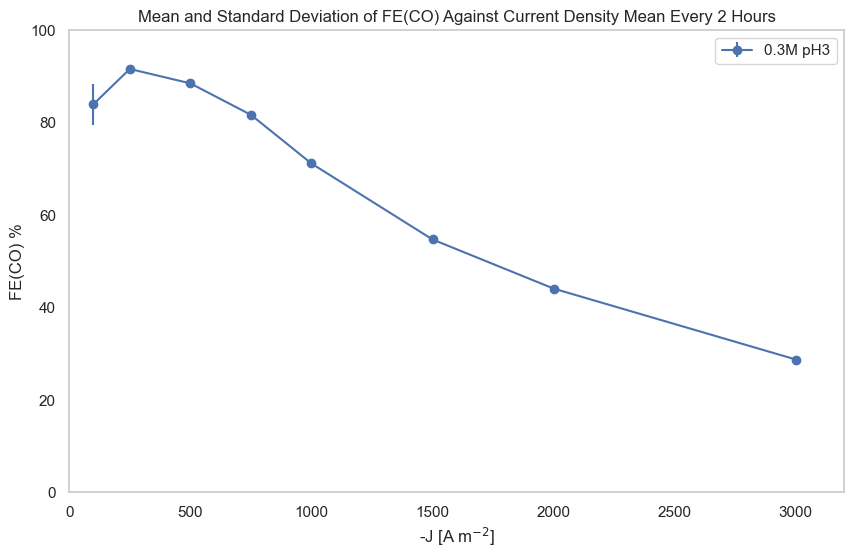

In [522]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.3M pH3')

# Formatting the plot
ax.set_xlabel(r'-J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3200)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240513_0.3M_pH2_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()

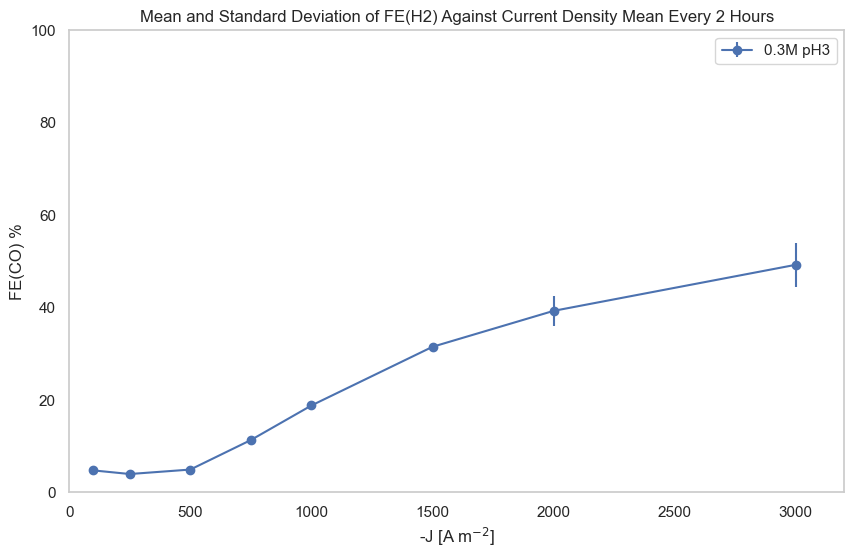

In [523]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(H2)_mean'], 
            yerr=Res_Book['FE(H2)_sem'], fmt='-o', label='0.3M pH3')

# Formatting the plot
ax.set_xlabel(r'-J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3200)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(H2) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240513_0.3M_pH2_mean_std_FE(H2)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()